# Camera-Relative Spatial Graph — Validation Notebook

End-to-end exercise of `camera_spatial_graph.CameraSpatialGraph` + `image_view_matcher.GraphImageMatcher`: load/validate the graph, embed the reference bank, locate a current image and a target (by node_id or by image), extract a deterministic route between them, and verify that replaying the extracted actions on a fresh `vtkCamera` actually reaches the target camera state.

Deterministic flow only — no LLM is involved anywhere in this notebook: `query image -> image embedding -> nearest graph node -> shortest path -> camera actions`.

## 1. Configuration

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
# Image paths inside camera_graph.json are stored relative to the repo root (as
# written by camera_relative_views.py, which is normally run from there) — chdir
# so every path below (and every path read back out of the graph) resolves the
# same way from this notebook.
os.chdir(os.path.abspath('..'))

GRAPH_PATH = "reference_views_relative/camera_graph.json"
EMBEDDING_CACHE_PATH = "reference_views_relative/graph_embeddings.pkl"

# The "current" image to locate on the graph.
CURRENT_IMAGE_PATH = "reference_views_relative/view_013.png"

# Target: set exactly one of these two.
#   TARGET_NODE_ID     -- an explicit graph node_id, e.g. "view_007"
#   TARGET_IMAGE_PATH  -- an image to resolve to a node via embedding match instead
TARGET_NODE_ID = "view_007"
TARGET_IMAGE_PATH = None

REPLAY_TOLERANCE = 1e-2  # max allowed numerical error in Part 9 (position/focal_point/view_up/DOP units)

## 2. Load and validate the graph

In [2]:
from camera_reasoning.camera_spatial_graph import CameraSpatialGraph

graph = CameraSpatialGraph.from_json(GRAPH_PATH)

print(f"Nodes: {len(graph.nodes)}")
print(f"Edges: {len(graph.edges)}")
print(f"Root node: {graph.root_node_id}")
print(f"Connected: {graph.is_connected()}")

try:
    graph.validate()
    print("Validation: PASSED")
except ValueError as e:
    print("Validation: FAILED")
    print(e)
    raise

Nodes: 18
Edges: 34
Root node: view_000
Connected: True
Validation: PASSED


## 3. Visualize the graph

Each pair of opposite directed edges (forward + inverse) is drawn as a single arrow labeled with the forward action, so directions and actions stay inspectable without clutter. Node labels are the neutral `node_id`s only.

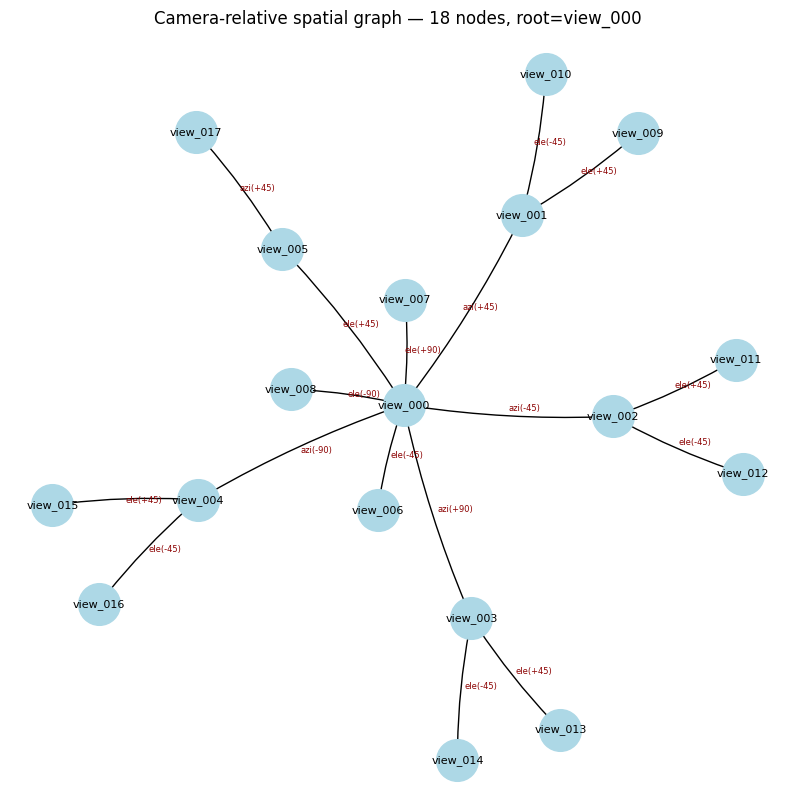

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.spring_layout(graph._graph, seed=7)
nx.draw_networkx_nodes(graph._graph, pos, node_color="lightblue", node_size=900, ax=ax)
nx.draw_networkx_labels(graph._graph, pos, font_size=8, ax=ax)

drawn = set()
for u, v, data in graph._graph.edges(data=True):
    if (v, u) in drawn:
        continue
    drawn.add((u, v))
    nx.draw_networkx_edges(
        graph._graph, pos, edgelist=[(u, v)], ax=ax, arrows=True,
        connectionstyle="arc3,rad=0.05",
    )
    action = data["action"]
    label = f"{action['type'][:3]}({action['degrees']:+.0f})"
    xm, ym = (pos[u][0] + pos[v][0]) / 2, (pos[u][1] + pos[v][1]) / 2
    ax.text(xm, ym, label, fontsize=6, color="darkred")

ax.set_title(f"Camera-relative spatial graph — {len(graph.nodes)} nodes, root={graph.root_node_id}")
ax.axis("off")
plt.show()

## 4. Build (or load) reference-node embeddings

In [5]:
from camera_reasoning.image_view_matcher import GraphImageMatcher, save_contact_sheet

matcher = GraphImageMatcher(graph, cache_path=EMBEDDING_CACHE_PATH)
matcher.build_index()

print(f"Model: {matcher.model_name}")
print(f"Device: {matcher.device}")
print(f"Indexed {len(matcher.index)} nodes")

[image_view_matcher] Loaded 18 cached graph-node embeddings from reference_views_relative/graph_embeddings.pkl
Model: openai/clip-vit-base-patch32
Device: cpu
Indexed 18 nodes


## 5. Insert the current image

Displays `CURRENT_IMAGE_PATH`, computes its embedding, and reports the best-matching node, confidence margin, ambiguity flag, and top-5 matches with thumbnails.

Current image:


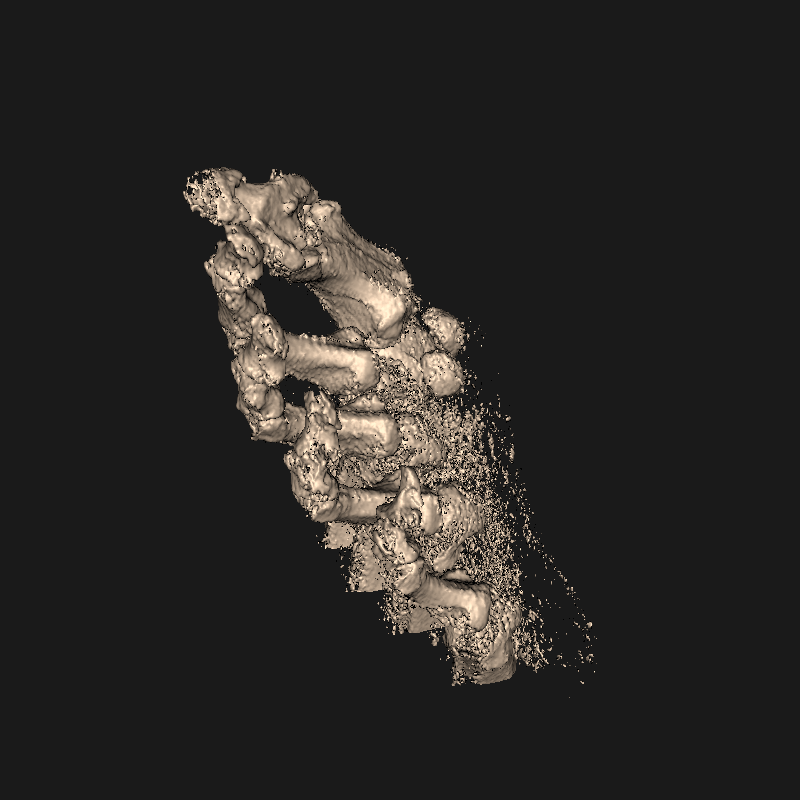

/Users/chulu/Documents/llm-vis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[image_view_matcher] Loading 'openai/clip-vit-base-patch32' on cpu...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



Best node: view_013
Confidence margin: 0.053421
Ambiguous: False

Top-5 matches:
  1. view_013   similarity=1.0000
  2. view_011   similarity=0.9466
  3. view_004   similarity=0.9423
  4. view_003   similarity=0.9335
  5. view_016   similarity=0.9312


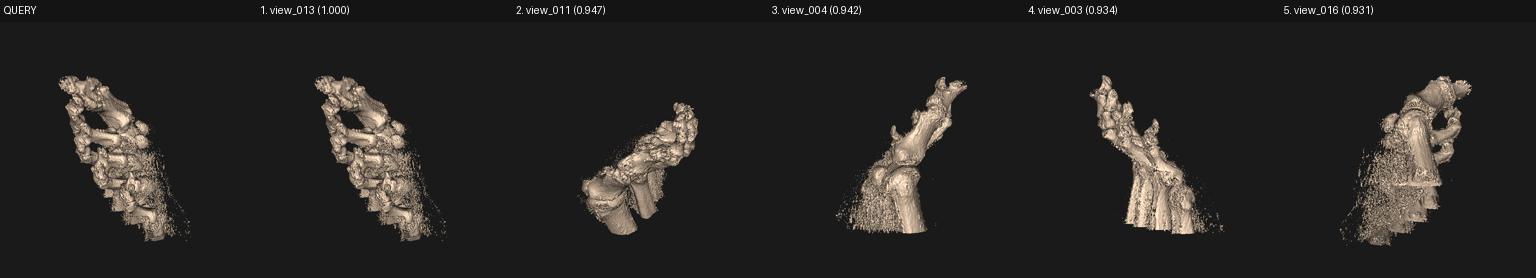

In [6]:
from IPython.display import Image, display

print("Current image:")
display(Image(CURRENT_IMAGE_PATH))

current_result = matcher.match(CURRENT_IMAGE_PATH, top_k=5)
current_node_id = current_result["best_node_id"]

print(f"\nBest node: {current_node_id}")
print(f"Confidence margin: {current_result['confidence_margin']}")
print(f"Ambiguous: {current_result['is_ambiguous']}")

print("\nTop-5 matches:")
for m in current_result["top_matches"]:
    print(f"  {m['rank']}. {m['node_id']:<10s} similarity={m['similarity']:.4f}")

save_contact_sheet(CURRENT_IMAGE_PATH, current_result["top_matches"], "output/graph_current_image_matches.png")
display(Image("output/graph_current_image_matches.png"))

## 6. Resolve the target node

Supports either an explicit `TARGET_NODE_ID`, or matching `TARGET_IMAGE_PATH` against the graph the same way the current image was matched.

In [7]:
if TARGET_NODE_ID:
    target_node_id = TARGET_NODE_ID
    if target_node_id not in graph.nodes:
        raise ValueError(f"TARGET_NODE_ID {target_node_id!r} is not a node in the graph")
    print(f"Target resolved from TARGET_NODE_ID: {target_node_id}")
elif TARGET_IMAGE_PATH:
    display(Image(TARGET_IMAGE_PATH))
    target_result = matcher.match(TARGET_IMAGE_PATH, top_k=5)
    target_node_id = target_result["best_node_id"]
    print(f"Target resolved from TARGET_IMAGE_PATH via embedding match: {target_node_id}")
    print(f"Confidence margin: {target_result['confidence_margin']}  Ambiguous: {target_result['is_ambiguous']}")
else:
    raise ValueError("Set exactly one of TARGET_NODE_ID or TARGET_IMAGE_PATH in the Configuration cell.")

print(f"\nSource node (current): {current_node_id}")
print(f"Target node: {target_node_id}")

Target resolved from TARGET_NODE_ID: view_007

Source node (current): view_013
Target node: view_007


## 7. Extract the path

Shortest node path + per-step actions, as a table and as a machine-readable action list.

In [8]:
import pandas as pd
import json as _json

route = graph.route(current_node_id, target_node_id)

print(f"Source: {route['source_node_id']}")
print(f"Target: {route['target_node_id']}")
print(f"Node path: {' -> '.join(route['node_path'])}")
print(f"Total cost: {route['total_cost']}")

table_rows = []
for i, (u, v, action) in enumerate(zip(route["node_path"], route["node_path"][1:], route["actions"])):
    edge_data = graph._graph.get_edge_data(u, v)
    table_rows.append({
        "step": i + 1,
        "source": u,
        "target": v,
        "action_type": action["type"],
        "degrees": action["degrees"],
        "cost": edge_data["cost"],
    })
route_table = pd.DataFrame(table_rows)
display(route_table)

action_list = [{"type": a["type"], "degrees": a["degrees"]} for a in route["actions"]]
print("\nMachine-readable action list:")
print(_json.dumps(action_list, indent=2))

Source: view_013
Target: view_007
Node path: view_013 -> view_003 -> view_000 -> view_007
Total cost: 3.0


,step,source,target,action_type,degrees,cost
0,1,view_013,view_003,elevation,-45.0,1.0
1,2,view_003,view_000,azimuth,-90.0,1.0
2,3,view_000,view_007,elevation,90.0,1.0



Machine-readable action list:
[
  {
    "type": "elevation",
    "degrees": -45.0
  },
  {
    "type": "azimuth",
    "degrees": -90.0
  },
  {
    "type": "elevation",
    "degrees": 90.0
  }
]


## 8. Display images along the route

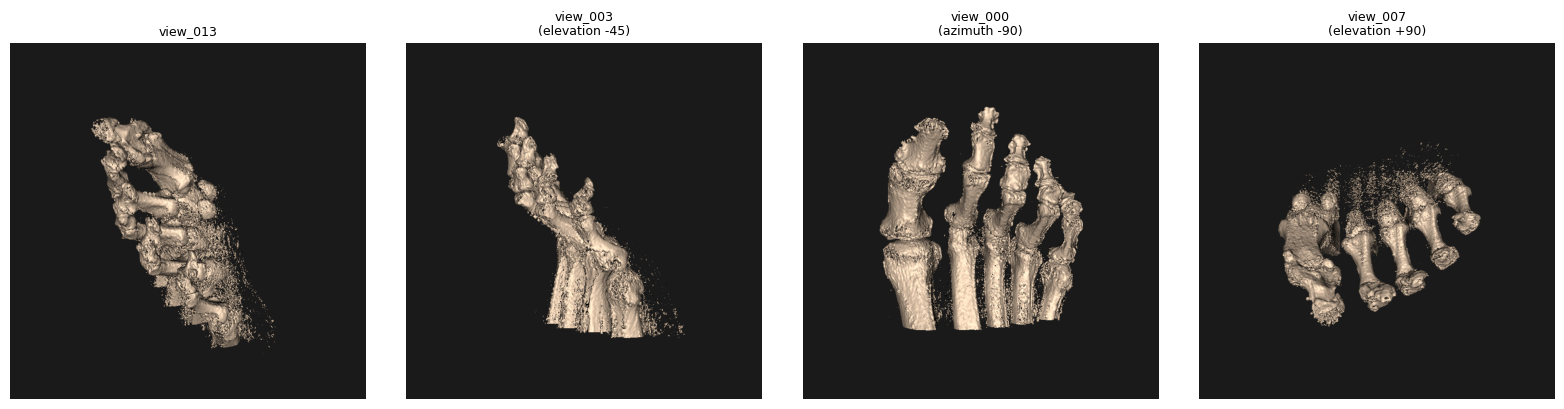

In [9]:
n = len(route["node_path"])
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for i, node_id in enumerate(route["node_path"]):
    img = plt.imread(graph.nodes[node_id]["image_path"])
    axes[i].imshow(img)
    axes[i].axis("off")
    if i == 0:
        title = node_id
    else:
        action = route["actions"][i - 1]
        title = f"{node_id}\n({action['type']} {action['degrees']:+.0f})"
    axes[i].set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

## 9. Verify action replay

Initializes a fresh `vtkCamera` from the source node's saved camera metadata, applies each extracted action in order (`OrthogonalizeViewUp()` after each), and compares the final state to the target node's saved camera metadata. Must pass (within `REPLAY_TOLERANCE`) for any route extracted from this graph, since every edge corresponds to a real, previously-applied VTK camera call.

In [10]:
import vtk
import numpy as np

def replay_and_verify(graph, route, tolerance=REPLAY_TOLERANCE):
    source_camera = graph.nodes[route["source_node_id"]]["camera"]
    target_camera = graph.nodes[route["target_node_id"]]["camera"]

    cam = vtk.vtkCamera()
    cam.SetPosition(*source_camera["position"])
    cam.SetFocalPoint(*source_camera["focal_point"])
    cam.SetViewUp(*source_camera["view_up"])

    for action in route["actions"]:
        if action["type"] == "azimuth":
            cam.Azimuth(action["degrees"])
        elif action["type"] == "elevation":
            cam.Elevation(action["degrees"])
        else:
            raise ValueError(f"Unsupported action type: {action['type']!r}")
        cam.OrthogonalizeViewUp()

    errors = {
        "position": float(np.linalg.norm(np.array(cam.GetPosition()) - np.array(target_camera["position"]))),
        "focal_point": float(np.linalg.norm(np.array(cam.GetFocalPoint()) - np.array(target_camera["focal_point"]))),
        "view_up": float(np.linalg.norm(np.array(cam.GetViewUp()) - np.array(target_camera["view_up"]))),
        "direction_of_projection": float(np.linalg.norm(
            np.array(cam.GetDirectionOfProjection()) - np.array(target_camera["direction_of_projection"])
        )),
    }
    passed = all(err <= tolerance for err in errors.values())
    return passed, errors

passed, errors = replay_and_verify(graph, route)

print("Replay verification (source camera state + extracted actions -> target camera state):")
for field, err in errors.items():
    print(f"  {field:<24s} error={err:.6f}  (tolerance={REPLAY_TOLERANCE})")
print(f"\nResult: {'PASS' if passed else 'FAIL'}")
assert passed, "Action replay did not reach the target camera state within tolerance."

Replay verification (source camera state + extracted actions -> target camera state):
  position                 error=0.000000  (tolerance=0.01)
  focal_point              error=0.000000  (tolerance=0.01)
  view_up                  error=0.000000  (tolerance=0.01)
  direction_of_projection  error=0.000000  (tolerance=0.01)

Result: PASS
